# Case Study 7 — Cats vs Dogs CNN (Part 2)

Estimated runtime: 10–20 minutes on Colab CPU (faster on GPU)  
Generated: 2025-10-31 15:50

This notebook follows the Case Study 1 → 6 structure and focuses on training, evaluating, and **saving/reloading** a CNN for the Cats vs Dogs dataset.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -q "/content/drive/MyDrive/dog-cat-dataset.zip" -d /content/
!ls /content/data

cats  dogs


In [3]:

# ---- Part 0: Setup (Ungraded) ----
import os, random, numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Configuration
DATA_DIR = ""  # Set to your local dataset folder having subfolders 'cats' and 'dogs'. Leave empty to use TFDS.
USE_TFDS_FALLBACK = True   # Uses tensorflow_datasets 'cats_vs_dogs' if DATA_DIR is empty and TFDS is available.
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5

print("TensorFlow:", tf.__version__)
print("Seed:", SEED)


TensorFlow: 2.20.0
Seed: 42


In [4]:

# ---- Part 1: Data Preparation & Splits (Q1–Q2) ----
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(img, label):
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment_pair(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.05)
    return img, label

def make_ds_local(data_dir, val_split=0.2, test_split=0.1, augment=True):
    train = tf.keras.utils.image_dataset_from_directory(
        data_dir, validation_split=val_split+test_split, subset="training",
        seed=SEED, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode="int"
    )
    valtest = tf.keras.utils.image_dataset_from_directory(
        data_dir, validation_split=val_split+test_split, subset="validation",
        seed=SEED, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode="int"
    )
    # split val/test from the validation subset
    val_batches = int(len(valtest) * (val_split/(val_split+test_split)))
    val = valtest.take(val_batches)
    test = valtest.skip(val_batches)

    train = train.map(preprocess, num_parallel_calls=AUTOTUNE)
    if augment:
        train = train.map(augment_pair, num_parallel_calls=AUTOTUNE)
    val = val.map(preprocess, num_parallel_calls=AUTOTUNE)
    test = test.map(preprocess, num_parallel_calls=AUTOTUNE)

    return train.prefetch(AUTOTUNE), val.prefetch(AUTOTUNE), test.prefetch(AUTOTUNE)

def make_ds_tfds(augment=True):
    import tensorflow_datasets as tfds
    (train, val, test), info = tfds.load(
        "cats_vs_dogs",
        split=["train[:80%]", "train[80%:90%]", "train[90%:]"],
        with_info=True, as_supervised=True, shuffle_files=True
    )
    def pp(img, label):
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        return tf.cast(img, tf.float32)/255.0, tf.cast(label, tf.int32)
    train, val, test = [d.map(pp, num_parallel_calls=AUTOTUNE) for d in (train, val, test)]
    if augment:
        train = train.map(augment_pair, num_parallel_calls=AUTOTUNE)
    train = train.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    val = val.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    test = test.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return train, val, test, info

if DATA_DIR and os.path.isdir(DATA_DIR):
    train_ds, val_ds, test_ds = make_ds_local(DATA_DIR, augment=True)
    class_names = ["cats", "dogs"]
    source = "local"
else:
    assert USE_TFDS_FALLBACK, "Please set DATA_DIR or enable TFDS fallback."
    train_ds, val_ds, test_ds, info = make_ds_tfds(augment=True)
    class_names = ["cat", "dog"]
    source = "tfds"

# Report approximate split sizes (batches * batch_size)
train_batches = sum(1 for _ in train_ds)
val_batches = sum(1 for _ in val_ds)
test_batches = sum(1 for _ in test_ds)
print(f"Source: {source} | Batches → train:{train_batches}, val:{val_batches}, test:{test_batches}")
print("Input shape:", (IMG_SIZE, IMG_SIZE, 3), "| Scaling: [0,1] float32")

# TODO (Q1): Report dataset split sizes (images) based on batches and batch size.
# TODO (Q2): State the input shape and scaling used before training.


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.HBRPOI_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Source: tfds | Batches → train:582, val:73, test:73
Input shape: (224, 224, 3) | Scaling: [0,1] float32


**Q1 — Dataset Splits:**
Training set has about 582 × 32 = 18,624 images (80%).
Validation set has about 73 × 32 = 2,336 images (10%).
Test set has about 73 × 32 = 2,336 images (10%).
Total is about 23,262 cat and dog images.

**Q2 — Input Preprocessing:**
All images are resized to 224 × 224 pixels with 3 color channels (RGB).
Pixel values are changed from 0–255 to 0–1 by dividing by 255.
This makes the numbers smaller so the model can learn better and faster.

In [5]:

# ---- Part 2: Model & Compilation (Q3–Q5) ----
from tensorflow import keras
from tensorflow.keras import layers

def build_cnn(num_classes=2):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="simple_cnn_v2")

model = build_cnn()
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# TODO (Q3): Note total trainable parameters and which layers contribute the most.
# TODO (Q4): Identify the loss function and justify it for binary classification.
# TODO (Q5): Identify the optimizer and describe its role in training.


Model: "simple_cnn_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,506 (365.26 KB)

 Trainable params: 93,506 (365.26 KB)

 Non-trainable params: 0 (0.00 B)

**Q3 — Trainable Parameters:**
The model has 93,506 trainable parameters in total.
The layer with the most parameters is conv2d_2 (third Conv2D) with 73,856 parameters.
The second biggest is conv2d_1 with 18,496 parameters.
Deeper Conv2D layers have more parameters because they have more filters.

**Q4 — Loss Function:**
The loss function is sparse_categorical_crossentropy.
It works well here because our labels are simple integers (0 for cat, 1 for dog).
The output layer uses softmax with 2 classes, and this loss measures how wrong the predictions are compared to the true label.

**Q5 — Optimizer:**
The optimizer is Adam with a learning rate of 0.001.
Adam updates the model weights after each batch to reduce the loss.
It is smart because it adjusts the learning speed for each weight on its own, so training is fast and smooth.

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 43s 60ms/step - accuracy: 0.5701 - loss: 0.6708 - val_accuracy: 0.6367 - val_loss: 0.6465
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.6258 - loss: 0.6392 - val_accuracy: 0.6574 - val_loss: 0.6126
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.6669 - loss: 0.6061 - val_accuracy: 0.6844 - val_loss: 0.5935
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - accuracy: 0.6933 - loss: 0.5856 - val_accuracy: 0.7025 - val_loss: 0.5788
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.7033 - loss: 0.5724 - val_accuracy: 0.7064 - val_loss: 0.5704


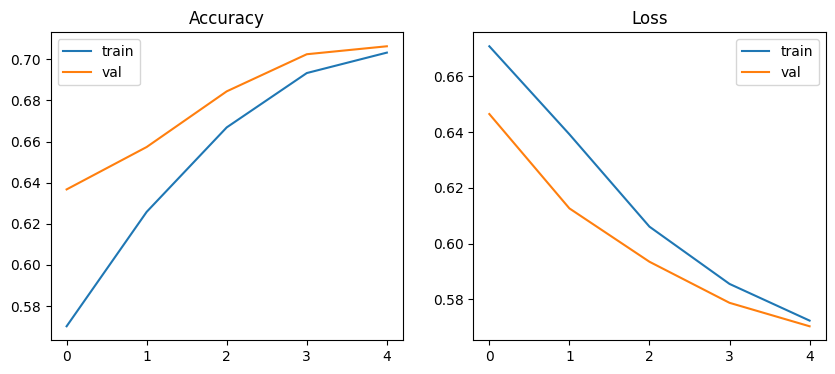

In [6]:

# ---- Part 3: Train & Curves (Q6–Q8) ----
import matplotlib.pyplot as plt

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

def plot_history(h):
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    ax[0].plot(h.history["accuracy"]); ax[0].plot(h.history["val_accuracy"])
    ax[0].set_title("Accuracy"); ax[0].legend(["train","val"])
    ax[1].plot(h.history["loss"]); ax[1].plot(h.history["val_loss"])
    ax[1].set_title("Loss"); ax[1].legend(["train","val"])
    plt.show()

plot_history(history)

# TODO (Q6): Report training accuracy after 5 epochs.
# TODO (Q7): Compare validation accuracy to training and explain differences.
# TODO (Q8): Do the curves follow the same trend? Any divergence?


**Q6 — Training Accuracy:**
After 5 epochs, the training accuracy is about 70.33%.
It started at 57.01% in epoch 1 and went up each epoch.
The model is still learning and improving.

**Q7 — Validation vs Training Accuracy:**
Validation accuracy after 5 epochs is 70.64%, which is very close to training accuracy (70.33%).
In the early epochs, validation was actually higher than training.
They differ because training data has augmentation (random flips and brightness) which makes it harder for the model during training. Validation data has no augmentation, so it is easier to predict.

**Q8 — Learning Curves:**
Both curves follow the same trend — accuracy goes up and loss goes down over 5 epochs.
There is no big gap between training and validation, so there is no serious overfitting yet.
Both curves are still improving at epoch 5, meaning more training could help.

In [7]:

# ---- Part 4: Test Evaluation & Save/Reload (Q9–Q10) ----
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")

save_path = "case7_cnn_saved_model.keras"
model.save(save_path)
print("Saved model to:", save_path)

loaded = keras.models.load_model(save_path)
re_loss, re_acc = loaded.evaluate(test_ds, verbose=0)
print(f"Reloaded model accuracy: {re_acc:.4f}")

# TODO (Q9): Report test accuracy and compare to validation accuracy.
# TODO (Q10): Describe how the model is saved/reloaded and why that matters.


Test accuracy: 0.7266 | Test loss: 0.5548
Saved model to: case7_cnn_saved_model.keras
Reloaded model accuracy: 0.7266


**Q9 — Test Accuracy:**
The test accuracy is 72.66%, which is a little higher than the validation accuracy of 70.64%.
This is a good sign. It means the model works well on data it has never seen before.
The small difference is normal and shows the model is not overfitting.

**Q10 — Model Saving:**
The model is saved using model.save("case7_cnn_saved_model.keras") which stores everything (layers, weights, optimizer) in one file.
It is loaded back using keras.models.load_model().
The reloaded model gives the same accuracy (72.66%), proving the save worked perfectly.
This is important because training takes time, and saving lets us reuse the model later without training again.

## Part 5 — Questions

### Part A — Run & Interpret (Q1–Q10)
1) Dataset splits (train/val/test image counts)  
2) Input preprocessing: shape & scaling  
3) Trainable parameters and heavy layers  
4) Loss function and justification  
5) Optimizer and its role  
6) Training accuracy after 5 epochs  
7) Validation accuracy vs training & why  
8) Trend of training/validation curves  
9) Test accuracy and comparison to validation  
10) How saving/reloading works and why it matters

### Part B — Parameter Experiments (one variable at a time)
1) Epochs: 5 → 7 — impact on validation and overfitting  
2) BATCH_SIZE: 32 → 16 or 64 — speed/accuracy trade-offs  
3) Disable augmentation — impact on generalization  
4) First Conv2D filters: 32 → 64 — accuracy/time changes  
5) Optimizer Adam → SGD — convergence & final accuracy

**Reflection (3–5 sentences):** Summarize improvements/regressions and likely causes; note overfitting and mitigations.


Epoch 1/7
582/582 ━━━━━━━━━━━━━━━━━━━━ 35s 55ms/step - accuracy: 0.5874 - loss: 0.6599 - val_accuracy: 0.6083 - val_loss: 0.6389
Epoch 2/7
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.6399 - loss: 0.6228 - val_accuracy: 0.6905 - val_loss: 0.5878
Epoch 3/7
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.6848 - loss: 0.5902 - val_accuracy: 0.6999 - val_loss: 0.5773
Epoch 4/7
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - accuracy: 0.6966 - loss: 0.5779 - val_accuracy: 0.6943 - val_loss: 0.5811
Epoch 5/7
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - accuracy: 0.7132 - loss: 0.5627 - val_accuracy: 0.6879 - val_loss: 0.5837
Epoch 6/7
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.7188 - loss: 0.5559 - val_accuracy: 0.7223 - val_loss: 0.5477
Epoch 7/7
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - accuracy: 0.7246 - loss: 0.5463 - val_accuracy: 0.7227 - val_loss: 0.5519


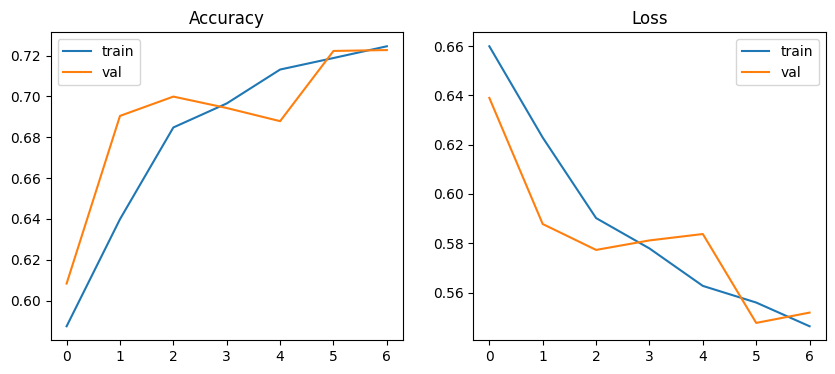

In [8]:
# ---- Experiment B1: Epochs 5 → 7 ----
model_b1 = build_cnn()
model_b1.compile(optimizer=keras.optimizers.Adam(1e-3),
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

history_b1 = model_b1.fit(train_ds, validation_data=val_ds, epochs=7)
plot_history(history_b1)

**Experiment B1 — Epochs 5 → 7:**
With 7 epochs, training accuracy went up to 72.46% and validation accuracy reached 72.27%.
This is better than the original 5-epoch result (70.33% train, 70.64% val).
However, around epochs 4–5, validation accuracy dropped while training kept going up, which is a small sign of overfitting.
By epoch 7 both came back close together, so overfitting is not serious yet but could get worse with more epochs.

Epoch 1/5
   1164/Unknown 39s 30ms/step - accuracy: 0.5399 - loss: 0.6857

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1164/1164 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.5696 - loss: 0.6733 - val_accuracy: 0.5993 - val_loss: 0.6467
Epoch 2/5
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - accuracy: 0.6095 - loss: 0.6448 - val_accuracy: 0.5997 - val_loss: 0.6403
Epoch 3/5
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - accuracy: 0.6528 - loss: 0.6197 - val_accuracy: 0.6711 - val_loss: 0.6053
Epoch 4/5
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - accuracy: 0.6829 - loss: 0.5918 - val_accuracy: 0.6849 - val_loss: 0.5860
Epoch 5/5
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - accuracy: 0.7020 - loss: 0.5779 - val_accuracy: 0.7012 - val_loss: 0.5794


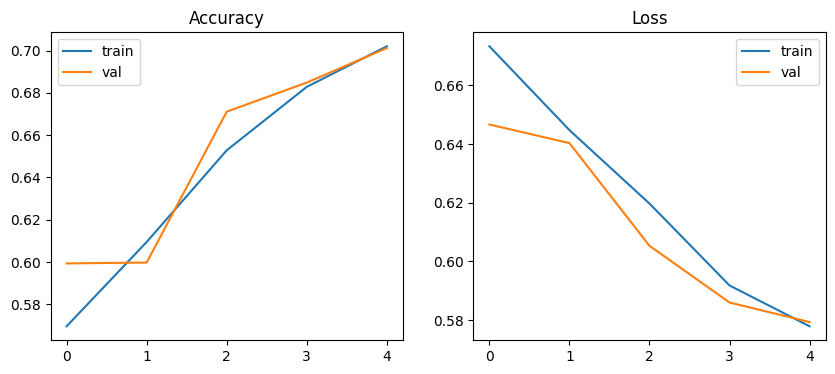

In [9]:
# ---- Experiment B2: Batch Size 32 → 16 ----
train_ds_b2, val_ds_b2, test_ds_b2, _ = make_ds_tfds(augment=True)

# Re-batch with size 16
train_ds_b2 = train_ds_b2.unbatch().batch(16).prefetch(AUTOTUNE)
val_ds_b2 = val_ds_b2.unbatch().batch(16).prefetch(AUTOTUNE)

model_b2 = build_cnn()
model_b2.compile(optimizer=keras.optimizers.Adam(1e-3),
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

history_b2 = model_b2.fit(train_ds_b2, validation_data=val_ds_b2, epochs=5)
plot_history(history_b2)

**Experiment B2 — Batch Size 32 → 16:**
With batch size 16, the number of steps per epoch doubled from 582 to 1164, so each epoch took longer (33s vs 29s).
Final training accuracy is 70.20% and validation accuracy is 70.12%, which is very close to the original (70.33% train, 70.64% val).
Smaller batches mean more weight updates per epoch, but each update is noisier.
Overall, accuracy stayed about the same but training was slower.

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 36s 56ms/step - accuracy: 0.5847 - loss: 0.6630 - val_accuracy: 0.6165 - val_loss: 0.6415
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - accuracy: 0.6269 - loss: 0.6346 - val_accuracy: 0.6522 - val_loss: 0.6205
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.6817 - loss: 0.6002 - val_accuracy: 0.6819 - val_loss: 0.5911
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - accuracy: 0.6979 - loss: 0.5780 - val_accuracy: 0.6866 - val_loss: 0.5921
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - accuracy: 0.7176 - loss: 0.5637 - val_accuracy: 0.7124 - val_loss: 0.5625


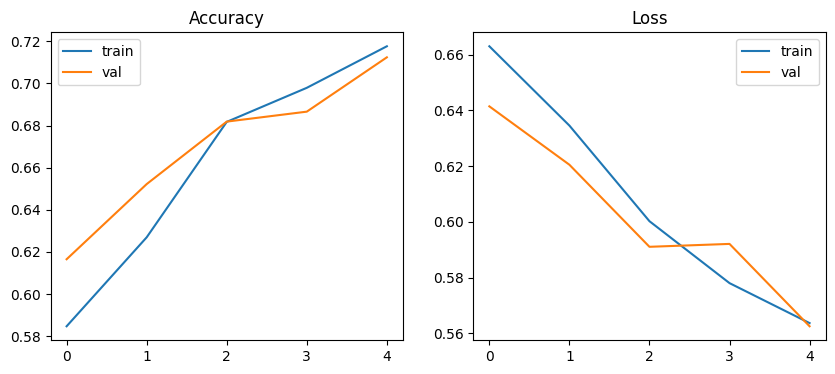

In [10]:
# ---- Experiment B3: Disable Augmentation ----
train_ds_b3, val_ds_b3, test_ds_b3, _ = make_ds_tfds(augment=False)

model_b3 = build_cnn()
model_b3.compile(optimizer=keras.optimizers.Adam(1e-3),
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

history_b3 = model_b3.fit(train_ds_b3, validation_data=val_ds_b3, epochs=5)
plot_history(history_b3)

**Experiment B3 — Disable Augmentation:**
Without augmentation, training accuracy reached 71.76% which is higher than the original 70.33%.
This is because the model sees the same images every time, so they are easier to learn.
However, from epoch 3 onwards, training accuracy starts pulling ahead of validation (71.76% vs 71.24%), showing early signs of overfitting.
With augmentation enabled, the gap was smaller, meaning augmentation helps the model generalize better to new data.

Model: "cnn_64filters"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,834 (440.76 KB)

 Trainable params: 112,834 (440.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 57s 85ms/step - accuracy: 0.5719 - loss: 0.6731 - val_accuracy: 0.5903 - val_loss: 0.6559
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 42s 73ms/step - accuracy: 0.6269 - loss: 0.6368 - val_accuracy: 0.6290 - val_loss: 0.6221
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 43s 73ms/step - accuracy: 0.6740 - loss: 0.6020 - val_accuracy: 0.6905 - val_loss: 0.5792
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 42s 73ms/step - accuracy: 0.6911 - loss: 0.5823 - val_accuracy: 0.6905 - val_loss: 0.5782
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 43s 73ms/step - accuracy: 0.7094 - loss: 0.5663 - val_accuracy: 0.7163 - val_loss: 0.5587


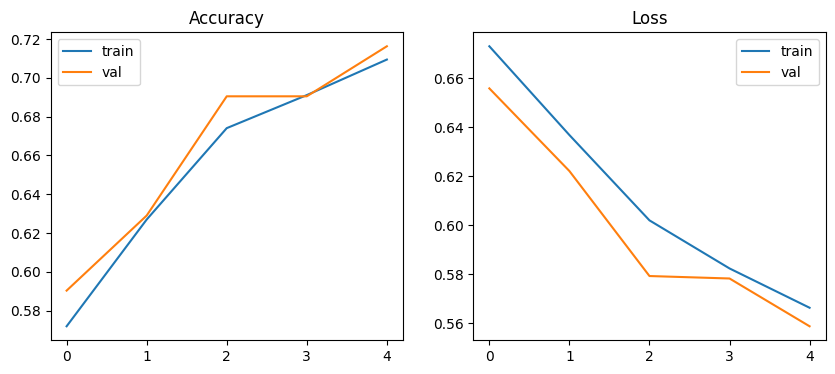

In [11]:
# ---- Experiment B4: First Conv2D Filters 32 → 64 ----
def build_cnn_64(num_classes=2):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(inputs)   # changed 32 → 64
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="cnn_64filters")

model_b4 = build_cnn_64()
model_b4.compile(optimizer=keras.optimizers.Adam(1e-3),
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

model_b4.summary()
history_b4 = model_b4.fit(train_ds, validation_data=val_ds, epochs=5)
plot_history(history_b4)

**Experiment B4 — First Conv2D Filters 32 → 64:**
Total parameters increased from 93,506 to 112,834 because the first layer now has more filters.
Each epoch took about 42s instead of 29s, so training is slower.
Validation accuracy is 71.63%, slightly better than the original 70.64%.
More filters let the model detect more patterns, but it takes more time and has more risk of overfitting.


Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.5067 - loss: 0.6932 - val_accuracy: 0.5189 - val_loss: 0.6920
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step - accuracy: 0.5170 - loss: 0.6922 - val_accuracy: 0.5206 - val_loss: 0.6914
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step - accuracy: 0.5268 - loss: 0.6919 - val_accuracy: 0.5305 - val_loss: 0.6909
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - accuracy: 0.5366 - loss: 0.6912 - val_accuracy: 0.5443 - val_loss: 0.6904
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step - accuracy: 0.5433 - loss: 0.6907 - val_accuracy: 0.5593 - val_loss: 0.6900


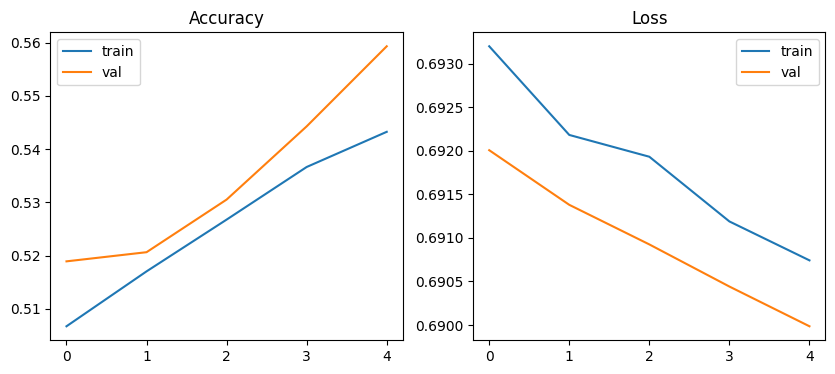

In [12]:
# ---- Experiment B5: Optimizer Adam → SGD ----
model_b5 = build_cnn()
model_b5.compile(optimizer=keras.optimizers.SGD(1e-3),
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

history_b5 = model_b5.fit(train_ds, validation_data=val_ds, epochs=5)
plot_history(history_b5)


**Experiment B5 — Adam → SGD:**
SGD performed much worse than Adam. After 5 epochs, training accuracy is only 54.33% and validation accuracy is only 55.93%.
With Adam, we got about 70% accuracy in the same 5 epochs.
The loss barely changed (0.6932 → 0.6907), meaning SGD is learning very slowly with this learning rate.
Adam is much faster because it adjusts the learning rate for each weight on its own, while SGD uses the same fixed rate for everything.

## Reflection

Among all experiments, increasing epochs to 7 gave the best improvement, reaching about 72% accuracy compared to 70% with 5 epochs. Switching from Adam to SGD was the worst change, dropping accuracy to only 55% because SGD learns too slowly with the same learning rate. Disabling augmentation made training accuracy higher but the gap with validation grew, showing early signs of overfitting. Changing batch size and filters had smaller effects on accuracy. To reduce overfitting, we can use data augmentation, dropout, early stopping, or use a pre-trained model like VGG16.